In [16]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from astropy.table import Table
from astropy.table import vstack as tab_vstack
from astropy.table import join as tab_join

from lvmdap.dap_tools import list_columns,read_DAP_file,map_plot_DAP,scatter
from matplotlib import use as mpl_use
#mpl_use('Agg')
from lvmdap.dap_tools import plot_spectra, read_coeffs_RSP, read_elines_RSP, read_tab_EL

%matplotlib inline
from matplotlib import rcParams as rc
rc.update({'font.size': 19,\
           'font.weight': 900,\
           'text.usetex': True,\
           'path.simplify'           :   True,\
           'xtick.labelsize' : 19,\
           'ytick.labelsize' : 19,\
#           'xtick.major.size' : 3.5,\
#           'ytick.major.size' : 3.5,\
           'axes.linewidth'  : 2.0,\
               # Increase the tick-mark lengths (defaults are 4 and 2)
           'xtick.major.size'        :   6,\
           'ytick.major.size'        :   6,\
           'xtick.minor.size'        :   3,\
           'ytick.minor.size'        :   3,\
           'xtick.major.width'       :   1,\
           'ytick.major.width'       :   1,\
           'lines.markeredgewidth'   :   1,\
           'legend.numpoints'        :   1,\
           'xtick.minor.width'       :   1,\
           'ytick.minor.width'       :   1,\
           'legend.frameon'          :   False,\
           'legend.handletextpad'    :   0.3,\
           'font.family'    :   'serif',\
           'mathtext.fontset'        :   'stix',\
           'axes.facecolor' : "w",\
           
          })
import math
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mpl_colors
import datetime as dt
from astropy.table import MaskedColumn
DRPVER = "1.2.0"
DAPVER = '1.2.0.251218' 

In [4]:
#from my_utils import search_col
def search_col(tab,key):
    a_cols=[]
    for cols in tab.columns:
        if (cols.find(key)>-1):
            print(cols)
            a_cols.append(cols)
    return np.array(a_cols)

In [5]:
import os
import fnmatch

def find_files(directory, pattern):
    matches = []
    for root, dirnames, filenames in os.walk(directory):
        for filename in fnmatch.filter(filenames, pattern):
            matches.append(os.path.join(root, filename))
    return matches

def Table_mean_rows(input_table):
    mean_values = {}
    for col in input_table.colnames:
        if np.issubdtype(input_table[col].dtype, np.number):
            mean_values[col] = np.mean(input_table[col])
        else:
            mean_values[col] = None  # Handle non-numeric columns if necessary

        # Create a new table with the computed means
    mean_row = {col: [mean_values[col]] for col in input_table.colnames if mean_values[col] is not None}
    output_table = Table(mean_row)
#    output_table.add_column([''],name='id')
#    output_table.rename_columns(output_table.colnames, input_table.colnames)
    return output_table

#mpl.use('TkAgg')#,warn=False, force=True)
%matplotlib inline

In [6]:
from astropy.io import fits, ascii
from astropy.table import vstack as tab_vstack

In [7]:
t_DR20 = Table.read('tables/dr20_pointings_final_v1.2.0.csv')
#t_DR20['dapfile'] = 'junk'
a_files = []
for t_now in t_DR20:
    expnum = f"{int(t_now['expnum']):08d}"
    file = f'dap-rsp108-sn20-{expnum}.dap.fits.gz'
    a_files.append(file)
t_DR20['dapfile'] = np.array(a_files)

In [8]:
#list_sel = ('ra','dec','flux_pek_6562.85')
dap_files = t_DR20['dapfile']
print(dap_files)

              dapfile               
------------------------------------
dap-rsp108-sn20-00004171.dap.fits.gz
dap-rsp108-sn20-00004297.dap.fits.gz
dap-rsp108-sn20-00005355.dap.fits.gz
dap-rsp108-sn20-00005511.dap.fits.gz
dap-rsp108-sn20-00005512.dap.fits.gz
dap-rsp108-sn20-00005516.dap.fits.gz
dap-rsp108-sn20-00005517.dap.fits.gz
dap-rsp108-sn20-00005518.dap.fits.gz
dap-rsp108-sn20-00005519.dap.fits.gz
dap-rsp108-sn20-00005520.dap.fits.gz
                                 ...
dap-rsp108-sn20-00031610.dap.fits.gz
dap-rsp108-sn20-00031611.dap.fits.gz
dap-rsp108-sn20-00031613.dap.fits.gz
dap-rsp108-sn20-00031614.dap.fits.gz
dap-rsp108-sn20-00031615.dap.fits.gz
dap-rsp108-sn20-00031616.dap.fits.gz
dap-rsp108-sn20-00031619.dap.fits.gz
dap-rsp108-sn20-00031648.dap.fits.gz
dap-rsp108-sn20-00031650.dap.fits.gz
dap-rsp108-sn20-00031651.dap.fits.gz
dap-rsp108-sn20-00031652.dap.fits.gz
Length = 169 rows


In [9]:
DIR_DAP = 'dap_v1.2.0/'
dap_files=t_DR20['dapfile']
verbose=True
verbose=False
ra=[]
dec=[]
idn=[]
I = 0
for II,dap_file in enumerate(dap_files):
    dap_file=f'{DIR_DAP}/{dap_file}'
    tab_DAP_tmp=read_DAP_file(dap_file,verbose=verbose)
    if (II==0):
        a_pek = search_col(tab_DAP_tmp,'flux_pek')
        a_st = search_col(tab_DAP_tmp,'_st')
        a_st_add = np.array(['Teff','e_Teff','Log_g','e_Log_g','Fe','e_Fe','alpha','e_alpha'])
        a_ini = np.array(['id','expnum','dapfile','ra','dec'])
        a_all = np.concatenate((a_ini,a_st_add,a_st,a_pek))        

    m_tab_DAP = Table_mean_rows(tab_DAP_tmp)
    m_tab_DAP.add_column([file],name='id')
    a_files = dap_file.split('/')
    m_tab_DAP['dapfile'] = a_files[-1]
    file_sec=a_files[-1].replace('dap-rsp108-sn20-','')
    file_sec=file_sec.replace('.dap.fits.gz','')
    m_tab_DAP['expnum']=int(file_sec) 

    tab_DAP_sec=m_tab_DAP[list(a_all)]        
    if (I==0):
        tab_DAP = tab_DAP_sec
    else:
        tab_DAP=tab_vstack([tab_DAP,tab_DAP_sec])
    I=I+1     
    #try:
    #    tab_DAP_sec=m_tab_DAP[list_sel]        
    #    if (I==0):
    #        tab_DAP = tab_DAP_sec
    #    else:
    #        tab_DAP=tab_vstack([tab_DAP,tab_DAP_sec])
    #    I=I+1        
    #except:
    #    print('Non equal files...')
    print(I,dap_file,II)
    

flux_pek_3726.03
e_flux_pek_3726.03
flux_pek_3728.82
e_flux_pek_3728.82
flux_pek_4101.77
e_flux_pek_4101.77
flux_pek_4340.49
e_flux_pek_4340.49
flux_pek_4861.36
e_flux_pek_4861.36
flux_pek_4958.91
e_flux_pek_4958.91
flux_pek_5006.84
e_flux_pek_5006.84
flux_pek_6300.3
e_flux_pek_6300.3
flux_pek_6548.05
e_flux_pek_6548.05
flux_pek_6562.85
e_flux_pek_6562.85
flux_pek_6583.45
e_flux_pek_6583.45
flux_pek_6716.44
e_flux_pek_6716.44
flux_pek_6730.82
e_flux_pek_6730.82
flux_pek_9069.0
e_flux_pek_9069.0
flux_pek_9531.1
e_flux_pek_9531.1
Av_st
e_Av_st
z_st
e_z_st
disp_st
e_disp_st
flux_st
redshift_st
med_flux_st
e_med_flux_st
vel_st
X_sq_st
X_sq_st_np
X_sq_st_pek
1 dap_v1.2.0//dap-rsp108-sn20-00004171.dap.fits.gz 0
2 dap_v1.2.0//dap-rsp108-sn20-00004297.dap.fits.gz 1
3 dap_v1.2.0//dap-rsp108-sn20-00005355.dap.fits.gz 2
4 dap_v1.2.0//dap-rsp108-sn20-00005511.dap.fits.gz 3
5 dap_v1.2.0//dap-rsp108-sn20-00005512.dap.fits.gz 4
6 dap_v1.2.0//dap-rsp108-sn20-00005516.dap.fits.gz 5
7 dap_v1.2.0//dap-rs

In [10]:
tab_DAP.remove_column('id')
tab_DAP['expnum','dapfile','ra','dec']

expnum,dapfile,ra,dec
int64,str36,float64,float64
4171,dap-rsp108-sn20-00004171.dap.fits.gz,84.12936332580028,-2.2599417918946134
4297,dap-rsp108-sn20-00004297.dap.fits.gz,337.4109445764032,-20.836237399255435
5355,dap-rsp108-sn20-00005355.dap.fits.gz,84.32565325314721,-2.6326914873987057
5511,dap-rsp108-sn20-00005511.dap.fits.gz,23.398469859677505,30.549733818078497
5512,dap-rsp108-sn20-00005512.dap.fits.gz,23.519019968508005,30.730334514752727
5516,dap-rsp108-sn20-00005516.dap.fits.gz,83.67916921155569,-2.9721628459990717
5517,dap-rsp108-sn20-00005517.dap.fits.gz,84.10059855660685,-2.9888785787894747
5518,dap-rsp108-sn20-00005518.dap.fits.gz,83.70824870154159,-2.243298286630511
5519,dap-rsp108-sn20-00005519.dap.fits.gz,83.93325354388995,-1.887172036918812


In [11]:
t_DR20['tilegrp','tileid','mjd','expnum','exptime']

tilegrp,tileid,mjd,expnum,exptime
str6,int64,int64,int64,float64
1028XX,1028800,60188,4171,900.0
0011XX,11111,60191,4297,900.0
1028XX,1028801,60208,5355,900.0
0011XX,11111,60212,5511,900.0
0011XX,11111,60212,5512,900.0
1028XX,1028740,60212,5516,900.0
1028XX,1028771,60212,5517,900.0
1028XX,1028769,60212,5518,900.0
1028XX,1028799,60212,5519,900.0


In [12]:
tab_dapall = tab_join(t_DR20['tilegrp','tileid','mjd','expnum','exptime'],tab_DAP,keys=['expnum'],join_type='left')

In [13]:
print(len(tab_dapall),len(tab_DAP),len(t_DR20))
#print(tab_dapall[tab_dapall['expnum']==4171])
#print(tab_DAP[tab_DAP['expnum']==4171])
tab_dapall

169 169 169


tilegrp,tileid,mjd,expnum,exptime,dapfile,ra,dec,Teff,e_Teff,Log_g,e_Log_g,Fe,e_Fe,alpha,e_alpha,Av_st,e_Av_st,z_st,e_z_st,disp_st,e_disp_st,flux_st,redshift_st,med_flux_st,e_med_flux_st,vel_st,X_sq_st,X_sq_st_np,X_sq_st_pek,flux_pek_3726.03,e_flux_pek_3726.03,flux_pek_3728.82,e_flux_pek_3728.82,flux_pek_4101.77,e_flux_pek_4101.77,flux_pek_4340.49,e_flux_pek_4340.49,flux_pek_4861.36,e_flux_pek_4861.36,flux_pek_4958.91,e_flux_pek_4958.91,flux_pek_5006.84,e_flux_pek_5006.84,flux_pek_6300.3,e_flux_pek_6300.3,flux_pek_6548.05,e_flux_pek_6548.05,flux_pek_6562.85,e_flux_pek_6562.85,flux_pek_6583.45,e_flux_pek_6583.45,flux_pek_6716.44,e_flux_pek_6716.44,flux_pek_6730.82,e_flux_pek_6730.82,flux_pek_9069.0,e_flux_pek_9069.0,flux_pek_9531.1,e_flux_pek_9531.1
str6,int64,int64,int64,float64,str36,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1028XX,1028800,60188,4171,900.0,dap-rsp108-sn20-00004171.dap.fits.gz,84.12936332580028,-2.2599417918946134,7540.78811494755,0.3989108084277238,3.6942547811655273,0.00022271722599596472,-1.8584627546752452,3.1816040471663274e-05,0.3119129889957459,7.5109500758592565e-06,0.0,0.0,3.1085406011960006e-05,-3.719240127206121e-12,6.224485711937142,0.0009514998590887736,232691.75427561087,3.1085406011960006e-05,85.76640922029374,38.85864006722528,9.319170276253466,6.631477600247588,6.631477600247588,6.631477600247588,1237.3815918472062,245.02475125427597,2231.747565051311,245.23484355758268,387.0621588939567,127.03302263397948,645.6362969213227,111.88611003420752,1411.9975493158495,94.92762525655645,43.80297155074116,89.54122559863168,131.5404569555302,91.98012468643103,4993.18000695553,84.79403540478904,519.2419869441277,64.99075074116305,6642.253507069555,80.8465023945268,1559.2852447548462,69.53099287343214,567.1738151083239,41.264967958950976,348.92373540478906,40.9188452109464,40.84329350057013,40.01887383124287,523.2926106043329,65.22272514253136
0011XX,11111,60191,4297,900.0,dap-rsp108-sn20-00004297.dap.fits.gz,337.4109445764032,-20.836237399255435,8144.617421362794,0.5122071665103127,3.6454624784335854,0.00030083201511796873,-0.8696818076773346,0.00013099398719714842,0.19731074472332938,1.8169286742227878e-05,0.057887873292282954,3.2503895224544163e-07,-0.00019399569756357635,-1.4725112988457068e-13,3.6964993574229084,8.088196031046686e-06,214472.3258901327,-0.00019399569756357635,14.894473759611145,18.815835013121006,-58.158447014009155,17.029836300729688,17.029836300729688,17.029836300729688,3071.895407069555,130.24456459521096,4365.384757126568,142.83126955530219,446.4613295895097,53.619041733181305,741.5649800456101,50.8796842645382,1595.2222341505133,73.74389555302167,2848.7290424173316,77.03752132269099,8554.741869099202,134.07507936145953,2878.719836659065,89.08267730900798,2837.863399885975,127.39743625997718,4649.488358095781,180.49336590649946,8522.112312827821,284.61759737742307,278.2489465222349,23.805212314709237,197.33527086659066,22.63213882554162,115.76098477765109,16.197249657924743,243.03778038768527,39.95508061573546
1028XX,1028801,60208,5355,900.0,dap-rsp108-sn20-00005355.dap.fits.gz,84.32565325314721,-2.6326914873987057,5341.942753102258,1.6680165048717541,3.029346897015714,0.001056926469350662,-0.6167829216561421,0.0002043044364225131,0.12158963084613511,4.400942063807644e-05,0.0017781704965208005,2.021333431007978e-08,-0.00012356195870238251,-3.60664255689363e-13,11.142583978857775,0.0020369048173303414,187809.84685067672,-0.00012356195870238251,19.3138220126837,11.772529067959697,-37.04294331468174,8.938271152280917,8.938271152280917,8.938271152280917,1742.8672550741164,92.43252514253136,2575.0224096

In [14]:
a_files = []
for files in tab_dapall['dapfile']:
    ungzip_file = files.replace('.gz', '')
    a_files.append(ungzip_file)
tab_dapall['dapfile'] = np.array(a_files)
tab_dapall

tilegrp,tileid,mjd,expnum,exptime,dapfile,ra,dec,Teff,e_Teff,Log_g,e_Log_g,Fe,e_Fe,alpha,e_alpha,Av_st,e_Av_st,z_st,e_z_st,disp_st,e_disp_st,flux_st,redshift_st,med_flux_st,e_med_flux_st,vel_st,X_sq_st,X_sq_st_np,X_sq_st_pek,flux_pek_3726.03,e_flux_pek_3726.03,flux_pek_3728.82,e_flux_pek_3728.82,flux_pek_4101.77,e_flux_pek_4101.77,flux_pek_4340.49,e_flux_pek_4340.49,flux_pek_4861.36,e_flux_pek_4861.36,flux_pek_4958.91,e_flux_pek_4958.91,flux_pek_5006.84,e_flux_pek_5006.84,flux_pek_6300.3,e_flux_pek_6300.3,flux_pek_6548.05,e_flux_pek_6548.05,flux_pek_6562.85,e_flux_pek_6562.85,flux_pek_6583.45,e_flux_pek_6583.45,flux_pek_6716.44,e_flux_pek_6716.44,flux_pek_6730.82,e_flux_pek_6730.82,flux_pek_9069.0,e_flux_pek_9069.0,flux_pek_9531.1,e_flux_pek_9531.1
str6,int64,int64,int64,float64,str33,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1028XX,1028800,60188,4171,900.0,dap-rsp108-sn20-00004171.dap.fits,84.12936332580028,-2.2599417918946134,7540.78811494755,0.3989108084277238,3.6942547811655273,0.00022271722599596472,-1.8584627546752452,3.1816040471663274e-05,0.3119129889957459,7.5109500758592565e-06,0.0,0.0,3.1085406011960006e-05,-3.719240127206121e-12,6.224485711937142,0.0009514998590887736,232691.75427561087,3.1085406011960006e-05,85.76640922029374,38.85864006722528,9.319170276253466,6.631477600247588,6.631477600247588,6.631477600247588,1237.3815918472062,245.02475125427597,2231.747565051311,245.23484355758268,387.0621588939567,127.03302263397948,645.6362969213227,111.88611003420752,1411.9975493158495,94.92762525655645,43.80297155074116,89.54122559863168,131.5404569555302,91.98012468643103,4993.18000695553,84.79403540478904,519.2419869441277,64.99075074116305,6642.253507069555,80.8465023945268,1559.2852447548462,69.53099287343214,567.1738151083239,41.264967958950976,348.92373540478906,40.9188452109464,40.84329350057013,40.01887383124287,523.2926106043329,65.22272514253136
0011XX,11111,60191,4297,900.0,dap-rsp108-sn20-00004297.dap.fits,337.4109445764032,-20.836237399255435,8144.617421362794,0.5122071665103127,3.6454624784335854,0.00030083201511796873,-0.8696818076773346,0.00013099398719714842,0.19731074472332938,1.8169286742227878e-05,0.057887873292282954,3.2503895224544163e-07,-0.00019399569756357635,-1.4725112988457068e-13,3.6964993574229084,8.088196031046686e-06,214472.3258901327,-0.00019399569756357635,14.894473759611145,18.815835013121006,-58.158447014009155,17.029836300729688,17.029836300729688,17.029836300729688,3071.895407069555,130.24456459521096,4365.384757126568,142.83126955530219,446.4613295895097,53.619041733181305,741.5649800456101,50.8796842645382,1595.2222341505133,73.74389555302167,2848.7290424173316,77.03752132269099,8554.741869099202,134.07507936145953,2878.719836659065,89.08267730900798,2837.863399885975,127.39743625997718,4649.488358095781,180.49336590649946,8522.112312827821,284.61759737742307,278.2489465222349,23.805212314709237,197.33527086659066,22.63213882554162,115.76098477765109,16.197249657924743,243.03778038768527,39.95508061573546
1028XX,1028801,60208,5355,900.0,dap-rsp108-sn20-00005355.dap.fits,84.32565325314721,-2.6326914873987057,5341.942753102258,1.6680165048717541,3.029346897015714,0.001056926469350662,-0.6167829216561421,0.0002043044364225131,0.12158963084613511,4.400942063807644e-05,0.0017781704965208005,2.021333431007978e-08,-0.00012356195870238251,-3.60664255689363e-13,11.142583978857775,0.0020369048173303414,187809.84685067672,-0.00012356195870238251,19.3138220126837,11.772529067959697,-37.04294331468174,8.938271152280917,8.938271152280917,8.938271152280917,1742.8672550741164,92.43252514253136,2575.022409692133,92.

In [17]:
DIR_out = 'tables/'
hdu_hdr = fits.PrimaryHDU()
hdu_hdr.header['DRPVER'] = DRPVER
hdu_hdr.header['DAPVER'] = DAPVER
hdu_hdr.header['DR'] = 'DR20'
hdu_hdr.header['DRPDATE'] = dt.datetime.now().isoformat()
hdu_DAP = fits.BinTableHDU(tab_dapall,name='DAPALL_DR20')
hdu_list = fits.HDUList([hdu_hdr,hdu_DAP])#,names=('PRIMARY','FLUX','ERROR','SKY'))
out_file = f'{DIR_out}/dapall-{DRPVER}-{DAPVER}.fits'
hdu_list.writeto(out_file,overwrite=True)

In [18]:
def map_plot_DAP_rgb(tab_DAP,\
                     rgb_key=('flux_pe_6583.45','flux_pe_6562.85','flux_pe_5006.84'), \
                     rgb_scale=(1.0,1.0,1.0),\
                 vmin=0, vmax=0, titles=('r','g','b'), filename='junk',\
                fsize=5, figs_dir='.',fig_type='png',\
                 gamma=1.0, sf=1.0, tab_pt=None,fs=18,x_scale=1,marker='O'):

    rc.update({'font.size': fs*fsize/5,\
               'font.weight': 900,\
               'text.usetex': True,\
               'path.simplify'           :   True,\
               'xtick.labelsize' : fs*fsize/5,\
               'ytick.labelsize' : fs*fsize/5,\
               'axes.linewidth'  : 2.0,\
               'xtick.major.size'        :   6,\
               'ytick.major.size'        :   6,\
               'xtick.minor.size'        :   3,\
               'ytick.minor.size'        :   3,\
               'xtick.major.width'       :   1,\
               'ytick.major.width'       :   1,\
               'lines.markeredgewidth'   :   1,\
               'legend.numpoints'        :   1,\
               'xtick.minor.width'       :   1,\
               'ytick.minor.width'       :   1,\
               'legend.frameon'          :   False,\
               'legend.handletextpad'    :   0.3,\
               'font.family'    :   'serif',\
               'mathtext.fontset'        :   'stix',\
               'axes.facecolor' : "w",\
               })
    
    X= tab_DAP['ra'].value
    Y= tab_DAP['dec'].value
    R=tab_DAP[rgb_key[2]].value  
    G=tab_DAP[rgb_key[1]].value    
    B=tab_DAP[rgb_key[0]].value 
    R = R * rgb_scale[2]
    G = G * rgb_scale[1]
    B = B * rgb_scale[0]
    RGB = np.stack((R, G, B), axis=1)
    if (vmin==vmax):
        vmin=np.nanmin(RGB)
        vmax=np.nanmax(RGB)
    print(f'min/max:{vmin}/{vmax}')
    r = (R-vmin)/(vmax-vmin)
    g = (G-vmin)/(vmax-vmin)
    b = (B-vmin)/(vmax-vmin)

    r[r>1]=1
    r[r<0]=0
    b[b>1]=1
    b[b<0]=0
    r[r>1]=1
    r[r<0]=0    
    
    r = np.ma.filled(r, fill_value=0.0)
    g = np.ma.filled(g, fill_value=0.0)
    b = np.ma.filled(b, fill_value=0.0)

    r=r**gamma
    g=g**gamma
    b=b**gamma
    
#    print (r)
    r = np.ma.compressed(r)
    g = np.ma.compressed(g)
    b = np.ma.compressed(b)   


    #print(r,g,b)
    colors = np.stack((r, g, b), axis=1)
    colors[colors>1]=1
    colors[colors<0]=0
#    print(colors)
    fig,ax = plt.subplots(1,1,figsize=(fsize*x_scale,fsize*0.95))
#    norm=mpl_colors.PowerNorm(vmin=0,vmax=1,gamma=gamma)
    scatter(X, Y, ax, color=colors, size=sf*35.6/3600,marker=marker)#, color=colors)
    ax.set_xlabel('Ra [deg]')#,fontsize=21)
    ax.set_ylabel('Dec [deg]')#,fontsize=21)
    xx = ax.get_xlim()
    yy = ax.get_ylim()
    ax.set_xlim(xx[1],xx[0])
    ax.text(xx[1]-0.03*(xx[1]-xx[0]),yy[1]-0.06*(yy[1]-yy[0]),titles[0],fontsize=fs*(fsize/5),color='tomato')
    ax.text(xx[1]-0.03*(xx[1]-xx[0]),yy[1]-0.12*(yy[1]-yy[0]),titles[1],fontsize=fs*(fsize/5),color='forestgreen')
    ax.text(xx[1]-0.03*(xx[1]-xx[0]),yy[1]-0.18*(yy[1]-yy[0]),titles[2],fontsize=fs*(fsize/5),color='steelblue')

    if (tab_pt != None):
        for tap_pt_now in tab_pt:
            ax.text(tab_pt['ra'],tab_pt['dec'],tab_pt['id'])
#    ax.set_aspect('equal', adjustable='box')
    try:
        plt.show()
    except:
        plt_show=False
    fig.tight_layout()
    fig.savefig(f'{figs_dir}/{filename}.{fig_type}', facecolor='white')
    plt.close()
    return colors


In [19]:
def map_plot_DAP_rgb(tab_DAP,\
                     rgb_key=('flux_pe_6583.45','flux_pe_6562.85','flux_pe_5006.84'), \
                     rgb_scale=(1.0,1.0,1.0),\
                 vmin=0, vmax=0, titles=('r','g','b'), filename='junk',\
                fsize=5, figs_dir='.',fig_type='png',\
                 gamma=1.0, sf=1.0, tab_pt=None,fs=18):

    rc.update({'font.size': fs*fsize/5,\
               'font.weight': 900,\
               'text.usetex': True,\
               'path.simplify'           :   True,\
               'xtick.labelsize' : fs*fsize/5,\
               'ytick.labelsize' : fs*fsize/5,\
               'axes.linewidth'  : 2.0,\
               'xtick.major.size'        :   6,\
               'ytick.major.size'        :   6,\
               'xtick.minor.size'        :   3,\
               'ytick.minor.size'        :   3,\
               'xtick.major.width'       :   1,\
               'ytick.major.width'       :   1,\
               'lines.markeredgewidth'   :   1,\
               'legend.numpoints'        :   1,\
               'xtick.minor.width'       :   1,\
               'ytick.minor.width'       :   1,\
               'legend.frameon'          :   False,\
               'legend.handletextpad'    :   0.3,\
               'font.family'    :   'serif',\
               'mathtext.fontset'        :   'stix',\
               'axes.facecolor' : "w",\
               })
    
    X= tab_DAP['ra'].value
    Y= tab_DAP['dec'].value
    R=tab_DAP[rgb_key[2]].value  
    G=tab_DAP[rgb_key[1]].value    
    B=tab_DAP[rgb_key[0]].value 
    R = R * rgb_scale[2]
    G = G * rgb_scale[1]
    B = B * rgb_scale[0]
    RGB = np.stack((R, G, B), axis=1)
    if (vmin==vmax):
        vmin=np.nanmin(RGB)
        vmax=np.nanmax(RGB)
    print(f'min/max:{vmin}/{vmax}')
    r = (R-vmin)/(vmax-vmin)
    g = (G-vmin)/(vmax-vmin)
    b = (B-vmin)/(vmax-vmin)

    r[r>1]=1
    r[r<0]=0
    b[b>1]=1
    b[b<0]=0
    r[r>1]=1
    r[r<0]=0    
    
    r = np.ma.filled(r, fill_value=0.0)
    g = np.ma.filled(g, fill_value=0.0)
    b = np.ma.filled(b, fill_value=0.0)

    r=r**gamma
    g=g**gamma
    b=b**gamma
    
#    print (r)
    r = np.ma.compressed(r)
    g = np.ma.compressed(g)
    b = np.ma.compressed(b)   


    #print(r,g,b)
    colors = np.stack((r, g, b), axis=1)
    colors[colors>1]=1
    colors[colors<0]=0
#    print(colors)
    fig,ax = plt.subplots(1,1,figsize=(fsize,fsize*0.95))
#    norm=mpl_colors.PowerNorm(vmin=0,vmax=1,gamma=gamma)
    scatter(X, Y, ax, color=colors, size=sf*35.6/3600)#, color=colors)
    ax.set_xlabel('Ra [deg]')#,fontsize=21)
    ax.set_ylabel('Dec [deg]')#,fontsize=21)
    xx = ax.get_xlim()
    yy = ax.get_ylim()
    ax.set_xlim(xx[1],xx[0])
    ax.text(xx[1]-0.03*(xx[1]-xx[0]),yy[1]-0.06*(yy[1]-yy[0]),titles[0],fontsize=fs*(fsize/5),color='tomato')
    ax.text(xx[1]-0.03*(xx[1]-xx[0]),yy[1]-0.12*(yy[1]-yy[0]),titles[1],fontsize=fs*(fsize/5),color='forestgreen')
    ax.text(xx[1]-0.03*(xx[1]-xx[0]),yy[1]-0.18*(yy[1]-yy[0]),titles[2],fontsize=fs*(fsize/5),color='steelblue')

    if (tab_pt != None):
        for tap_pt_now in tab_pt:
            ax.text(tab_pt['ra'],tab_pt['dec'],tab_pt['id'])
#    ax.set_aspect('equal', adjustable='box')
    try:
        plt.show()
    except:
        plt_show=False
    fig.tight_layout()
    fig.savefig(f'{figs_dir}/{filename}.{fig_type}', facecolor='white')
    plt.close()
    return colors


min/max:600.0/100000.0


/tmp/ipykernel_307671/2606146357.py:61: RuntimeWarning: invalid value encountered in power
  g=g**gamma


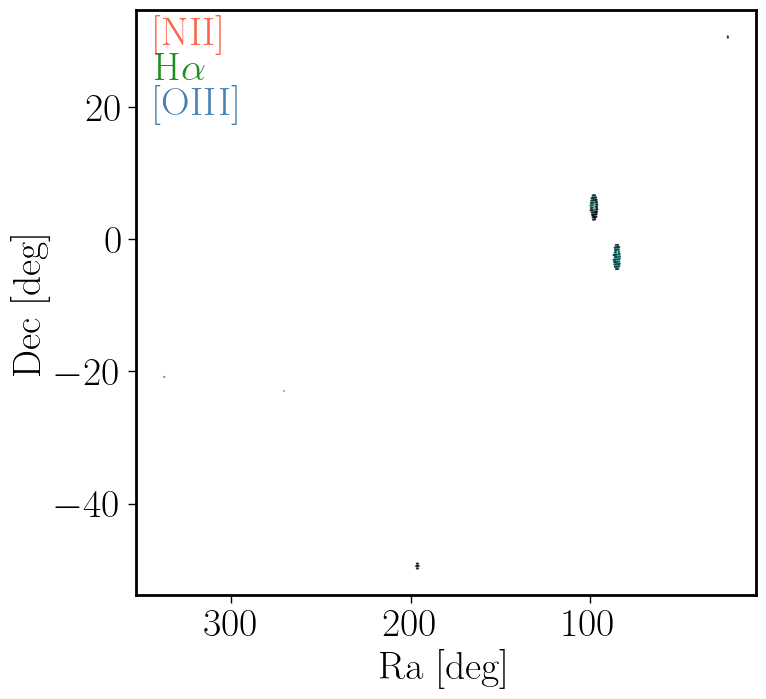

In [20]:
# 637.416/110230.7468
colors=map_plot_DAP_rgb(tab_dapall, \
                 rgb_key=('flux_pek_6583.45','flux_pek_6562.85','flux_pek_5006.84'), \
                 rgb_scale = (3,1,1.5), \
                 vmin=600.0, vmax=100000.0,\
                 titles=('[NII]',r'H$\alpha$','[OIII]'), filename='test',\
                 fsize=8, figs_dir='figs',gamma=0.35,fig_type='png',sf=10)#
#,fs=20,sf=19,x_scale=3)

(4.2, 2.2)

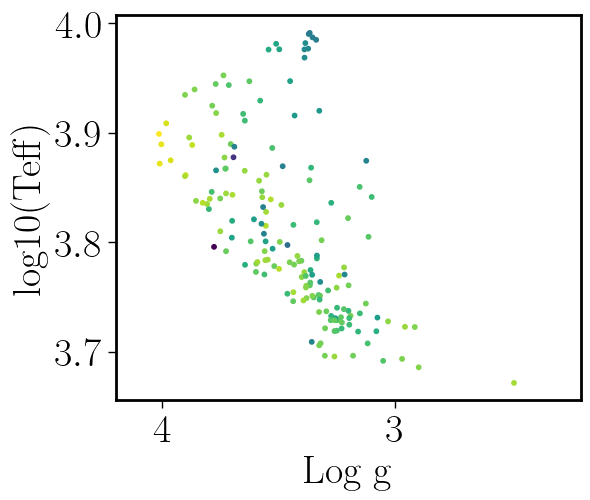

In [21]:
fig,ax = plt.subplots(1,1,figsize=(6,5))
ax.scatter(tab_dapall['Log_g'],np.log10(tab_dapall['Teff']),c=tab_dapall['Fe'],s=10)
ax.set_xlabel('Log g')
ax.set_ylabel('log10(Teff)')
ax.set_xlim(4.2,2.2)

Text(0, 0.5, '[$\\alpha$/Fe]')

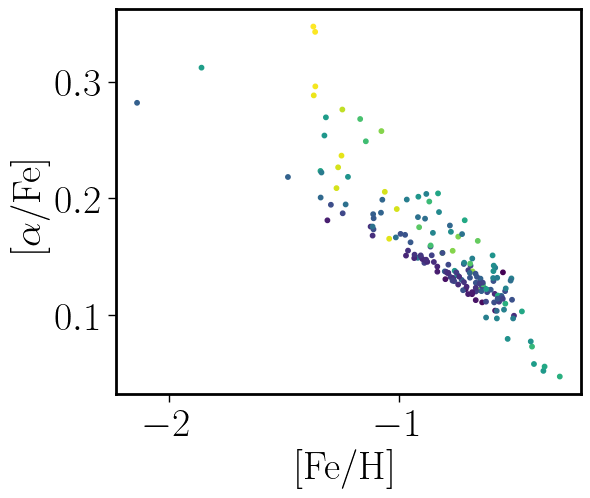

In [22]:
fig,ax = plt.subplots(1,1,figsize=(6,5))
ax.scatter(tab_dapall['Fe'],tab_dapall['alpha'],c=tab_dapall['Teff'],s=10)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel(r'[$\alpha$/Fe]')
#ax.set_xlim(4.2,2.2)
